In [1]:
# Import modules
%matplotlib inline
import os, sys
base_dir = "../../"
sys.path.extend([f"{base_dir}/postprocess"])
import numpy as np
import xarray as xr

# for plotting
from jupyter_plotting import *




In [2]:
class Config:
    def __init__(self):
        pass
config = Config()

In [3]:
#config parameters
config.base_folder = "/p/scratch/deepacf/maelstrom/maelstrom_data/ap5/downscaling_benchmark_dataset/benchmark_t2m/results"
config.variable = "t2m"
config.models = ["deepru","sha_unet","sha_wgan","swinir"]
config.seasons = "year"   #["year","DJF","JJA","MAM","SON"]
if config.seasons not in ["year","DJF","JJA","MAM","SON"]:
    raise ValueError("seasons should be one of [year, DJF, JJA, MAM, SON]")
config.metric = "bias" #["bias","grad_amplitude","me_std","rmse"]                     
if config.metric not in ["bias","grad_amplitude","me_std","rmse"]:
    raise ValueError("metric should be one of [bias, grad_amplitude, me_std, rmse]")
                 
            
                     

 # Line plot

In [4]:
nc_files_mean  = []
for model in config.models:
    model_path = os.path.join(config.base_folder,f"{model}_benchmark_{config.variable}","metric_files")
    nc_files_mean.append(os.path.join(model_path,f"eval_{config.metric}_{config.seasons}.nc"))
nc_files_std = []
if config.metric == "rmse":
    config.metric = "me_std"
    for model in config.models:
        model_path = os.path.join(config.base_folder,f"{model}_benchmark_{config.variable}","metric_files")
        nc_files_std.append(os.path.join(model_path,f"eval_{config.metric}_{config.seasons}.nc"))
    config.metric  "rmse"

In [5]:
#define metric
metric_name = f'{config.metric} {config.variable}' 
metric_unit = "$^\circ$C"
metric_dict = {metric_name:metric_unit}

In [6]:
mean_array = []
for nc_file_mean in nc_files_mean:
    data_array = xr.open_dataset(nc_file_mean)
    mean_array.append(data_array[f"{config.metric}_mean"])
if config.metric == "rmse":
    config.metric = 'me_std'
    std_array = []
    for nc_file_std in nc_files_std:
        data_array = xr.open_dataset(nc_file_std)
        std_array.append(data_array[f"{config.metric}_mean"])
    config.metric = 'rmse'
else :
    std_array = None
    

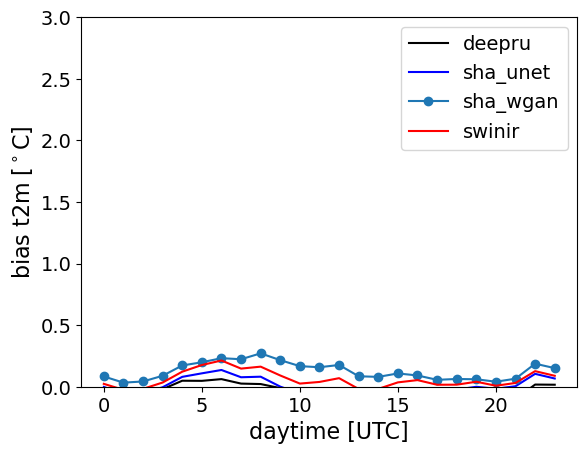

In [7]:
create_lines_plot(mean_array,std_array,config.models,metric_dict,"rmse")

# Box plot

In [8]:
mean_array_boot = []
for nc_file_mean in nc_files_mean:
    data_array = xr.open_dataset(nc_file_mean)
    mean_array_boot.append(np.expand_dims(np.mean(data_array[f"{config.metric}_mean_boot"],axis=0),axis=0))


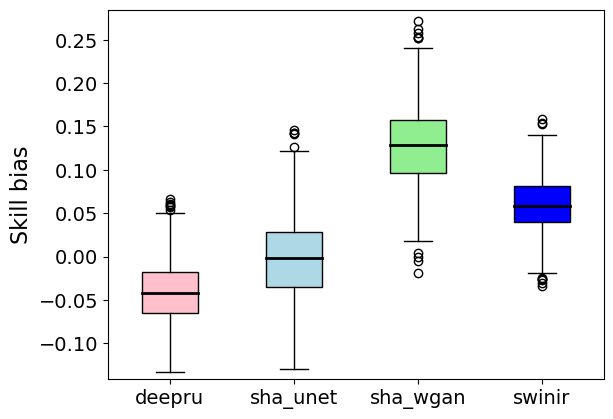

In [9]:
plot_skills(np.concatenate(mean_array_boot),"box_plot",labels=config.models, metric=config.metric)

# Model Comparison

In [4]:
file_paths = []
variable = config.variable
for model in config.models:
    file_path = os.path.join(config.base_folder,f"{model}_benchmark_{variable}",f"downscaled_{variable}_{model}.nc")
    file_paths.append(file_path)

In [5]:
ground_truth_array = []
forecast_array = []
difference_array = []

for file_path in file_paths:
    dataset = xr.open_dataset(file_path)
    ground_truth = dataset[f"{variable}_ref"]-273
    forecast = dataset[f"{variable}_fcst"]-273
    if config.seasons != "year":
        ground_truth = ground_truth[ground_truth["time.season"] == config.seasons]
        forecast = forecast[forecast["time.season"] == config.seasons]
    ground_truth_array.append(np.mean(ground_truth,axis=0))
    forecast_array.append(np.mean(forecast,axis=0))
    difference_array.append(forecast[-1]-ground_truth[-1])


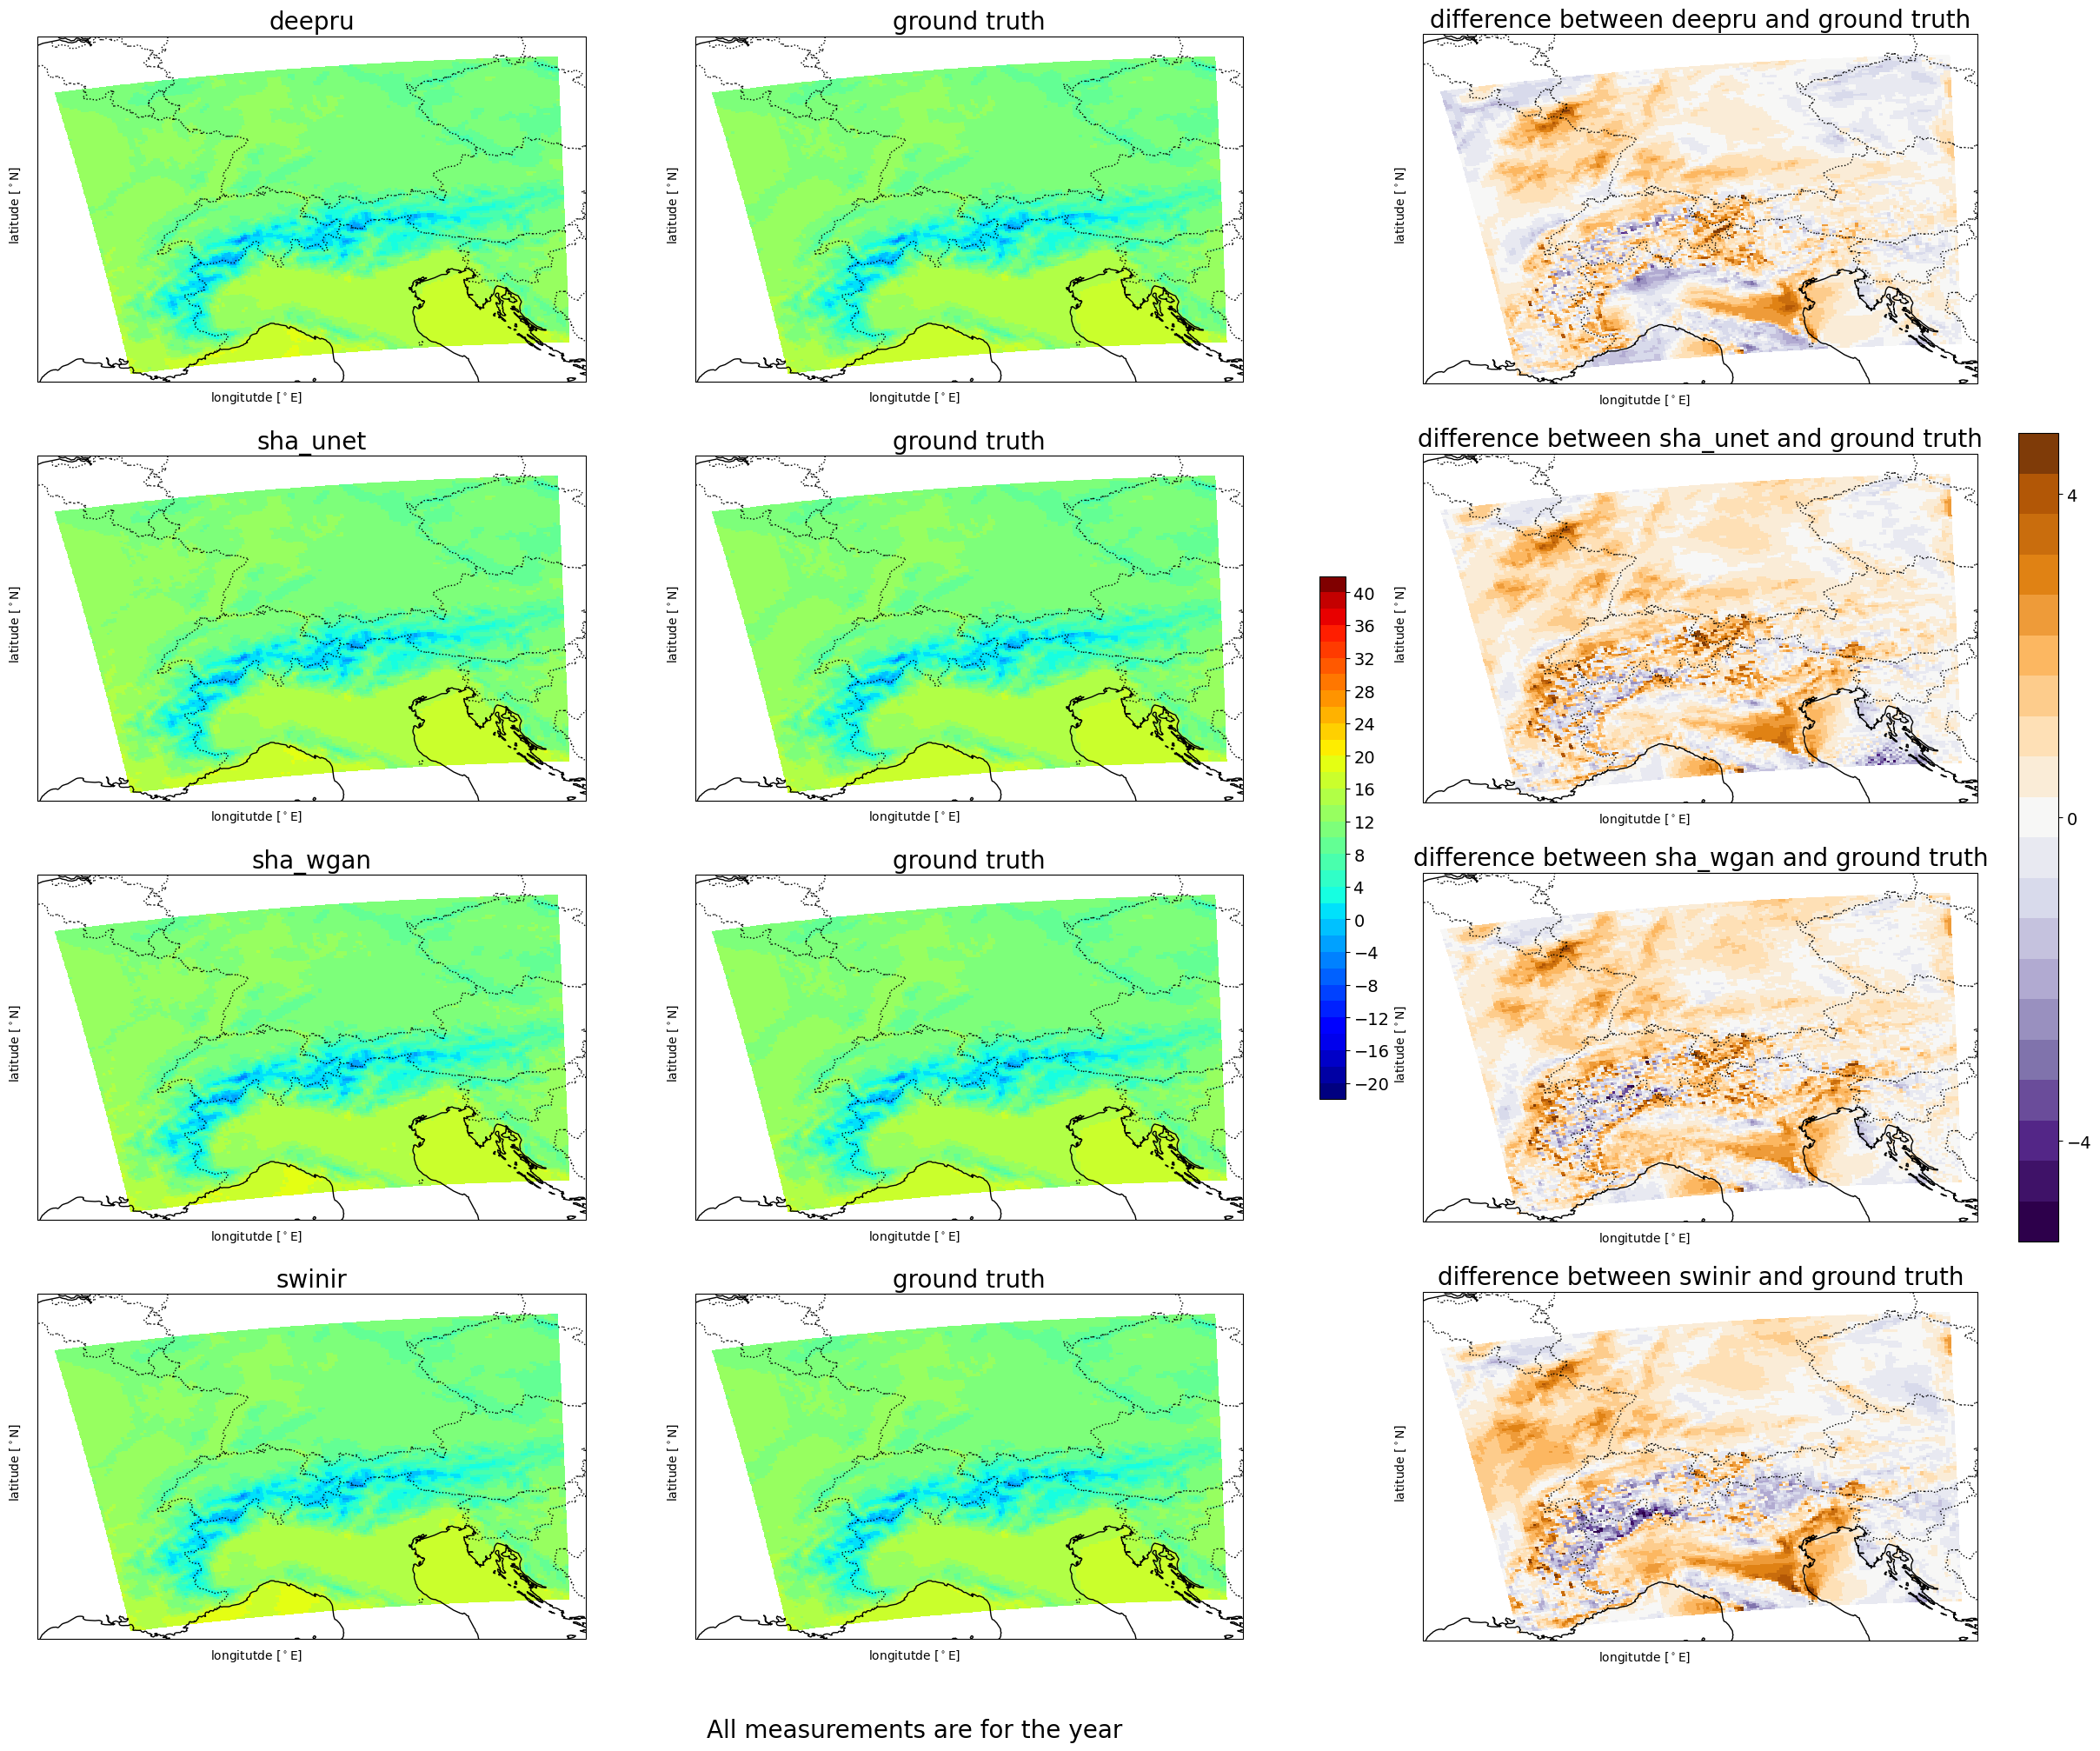

In [6]:
create_model_compare_plots(forecast_array,ground_truth_array,difference_array,config.models,"model_comparison",seasons=config.seasons)

## Energy Spectra